# Siddhesh — Exploratory Data Analysis

EDA on the merged county-level dataset built by sid_preprocessing.ipynb.

**Input:** `../data/processed/merged_county_dataset.csv`
**Output:** `../data/processed/model_ready_dataset.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


### (2) Load dataset

In [2]:
df = pd.read_csv(
    "../data/processed/merged_county_dataset.csv",
    dtype={"county_fips": str},
    low_memory=False
)

df["county_fips"] = df["county_fips"].astype(str).str.zfill(5)

print(f"Shape: {df.shape}")
print(f"States covered: {df['state'].nunique()}")
print(f"Duplicate FIPS: {df['county_fips'].duplicated().sum()}")
display(df.head(3))

Shape: (3115, 162)
States covered: 51
Duplicate FIPS: 0


,GEO_ID,NAME,county_fips,B01001_001E,B01001_002E,B01001_003E,B01001_004E,B01001_005E,B01001_006E,B01001_007E,B01001_008E,B01001_009E,B01001_010E,B01001_011E,B01001_012E,B01001_013E,B01001_014E,B01001_015E,B01001_016E,B01001_017E,B01001_018E,B01001_019E,B01001_020E,B01001_021E,B01001_022E,B01001_023E,B01001_024E,B01001_025E,B01001_026E,B01001_027E,B01001_028E,B01001_029E,B01001_030E,B01001_031E,B01001_032E,B01001_033E,B01001_034E,B01001_035E,B01001_036E,B01001_037E,B01001_038E,B01001_039E,B01001_040E,B01001_041E,B01001_042E,B01001_043E,B01001_044E,B01001_045E,B01001_046E,B01001_047E,B01001_048E,B01001_049E,B02001_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B02001_008E,B02001_009E,B02001_010E,B15003_001E,B15003_002E,B15003_003E,B15003_004E,B15003_005E,B15003_006E,B15003_007E,B15003_008E,B15003_009E,B15003_010E,B15003_011E,B15003_012E,B15003_013E,B15003_014E,B15003_015E,B15003_016E,B15003_017E,B15003_018E,B15003_019E,B15003_020E,B15003_021E,B15003_022E,B15003_023E,B15003_024E,B15003_025E,B19013_001E,B17001_001E,B17001_002E,B17001_003E,B17001_004E,B17001_005E,B17001_006E,B17001_007E,B17001_008E,B17001_009E,B17001_010E,B17001_011E,B17001_012E,B17001_013E,B17001_014E,B17001_015E,B17001_016E,B17001_017E,B17001_018E,B17001_019E,B17001_020E,B17001_021E,B17001_022E,B17001_023E,B17001_024E,B17001_025E,B17001_026E,B17001_027E,B17001_028E,B17001_029E,B17001_030E,B17001_031E,B17001_032E,B17001_033E,B17001_034E,B17001_035E,B17001_036E,B17001_037E,B17001_038E,B17001_039E,B17001_040E,B17001_041E,B17001_042E,B17001_043E,B17001_044E,B17001_045E,B17001_046E,B17001_047E,B17001_048E,B17001_049E,B17001_050E,B17001_051E,B17001_052E,B17001_053E,B17001_054E,B17001_055E,B17001_056E,B17001_057E,B17001_058E,B17001_059E,B23025_001E,B23025_002E,B23025_003E,B23025_004E,B23025_005E,B23025_006E,B23025_007E,B25001_001E,state,county_name,totalvotes,democrat_votes,republican_votes,party_winner,dem_vote_share
0,0500000US01001,"Autauga County, Alabama",01001,55639,27052,1727,2156,1674,1208,553,395,225,1127,1789,1669,2043,1394,2015,1937,2025,628,804,429,699,1077,764,389,325,28587,1508,1569,1971,1330,625,224,306,1181,1870,1750,1850,2017,1990,1874,2080,835,800,496,836,1414,1066,358,637,55639,42150,10866,155,649,24,374,1421,346,1075,37860,275,0,0,35,0,17,25,3,124,117,313,718,1250,728,668,9663,2217,2194,5469,3323,6320,3399,504,498,57982.0,55181,8394,3417,257,55,362,244,104,226,357,340,407,479,413,142,31,4977,423,102,770,245,23,214,322,736,676,337,695,281,153,46787,23364,1454,424,2117,594,181,697,1934,3025,2997,3439,3009,2057,1436,23423,1073,152,1318,934,366,727,2014,2884,3174,3507,3005,2460,1809,44360,26025,25316,24580,736,709,18335,23697,ALABAMA,AUTAUGA,27770,7503.0,19838.0,0,0.270184
1,0500000US01003,"Baldwin County, Alabama",01003,218289,105889,6082,5197,8289,4305,2406,1177,792,3581,6064,5977,6787,5979,6763,7037,7434,2273,5145,2762,3855,6007,4273,2163,1541,112400,5878,6362,6882,3998,2296,1245,1123,3113,6220,6126,7022,6623,7374,7396,7802,3702,5123,3058,4236,7008,4669,2556,2588,218289,186504,19153,1514,2033,10,3398,5677,1519,4158,155563,1451,0,63,0,123,70,198,78,638,275,938,1976,3127,2483,3403,34521,7751,10511,23964,14357,31444,13331,2845,2016,61756.0,215170,19739,7803,563,176,462,420,166,267,971,887,664,970,1256,657,344,11936,636,129,821,516,95,378,1111,1678,1060,923,2268,1192,1129,195431,96029,5451,878,6694,4797,1444,2401,6701,10733,11657,12655,13435,11820,7363,99402,5188,983,6370,4117,1030,2460,6446,10668,12563,13834,14316,13017,8410,176852,103116,102795,98768,4027,321,73736,116747,ALABAMA,BALDWIN,109679,24578.0,83544.0,0,0.224090
2,0500000US01005,"Barbour County, Alabama",01005,25026,13156,660,741,721,467,261,365,103,432,1150,1084,928,856,872,839,809,215,580,301,327,674,429,200,142,11870,672,809,708,444,214,138,54,440,696,713,694,569,659,755,782,360,459,222,566,766,474,335,341,25026,11587,11929,88,122,1,777,522,232,290,17797,384,0,0,0,82,124,7,24,69,233,464,621,971,1029,489,5171,1190,1018,2469,1385,1296,540,118,113,34990.0,22070,631

### (3) Missing values check

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values.")
else:
    print(f"{len(missing)} column(s) with missing values:")
    display(missing)

1 column(s) with missing values:


B19013_001E    1
dtype: int64

### (4) Target variable — class balance

party_winner
Republican    2576
Democrat       539
Name: count, dtype: int64

Imbalance ratio: 4.78x


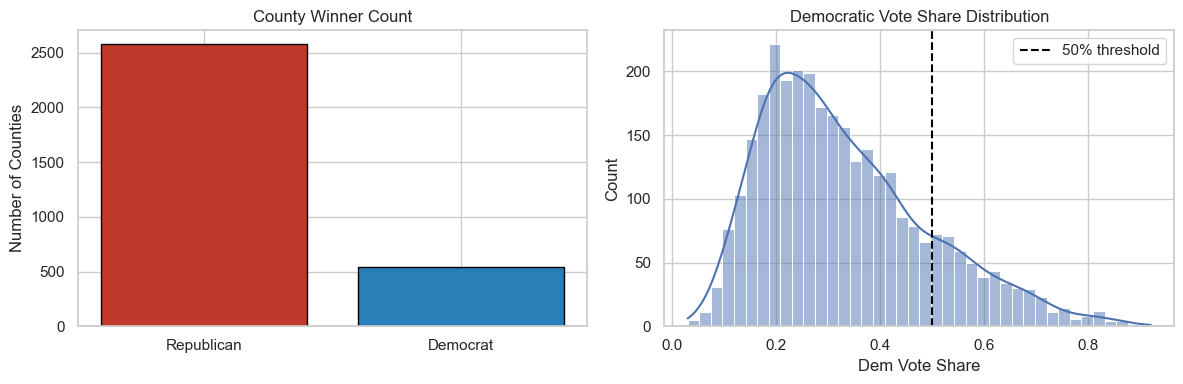

In [4]:
counts = df["party_winner"].value_counts().rename({1: "Democrat", 0: "Republican"})
print(counts)
print(f"\nImbalance ratio: {counts.max()/counts.min():.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Republican", "Democrat"],
            [counts["Republican"], counts["Democrat"]],
            color=["#c0392b", "#2980b9"], edgecolor="black")
axes[0].set_title("County Winner Count")
axes[0].set_ylabel("Number of Counties")

sns.histplot(df["dem_vote_share"], bins=40, kde=True, ax=axes[1])
axes[1].axvline(0.5, color="black", linestyle="--", label="50% threshold")
axes[1].set_title("Democratic Vote Share Distribution")
axes[1].set_xlabel("Dem Vote Share")
axes[1].legend()

plt.tight_layout()
plt.show()

### (5) Swing county analysis

Solid Republican (< 40%):  2204  (70.8%)
Swing           (40-60%):   673  (21.6%)
Solid Democrat  (> 60%):    238  (7.6%)


C:\Users\sidpa\AppData\Local\Temp\ipykernel_27792\3545345302.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["county_type"] = pd.cut(df["dem_vote_share"], bins=bins, labels=labels)


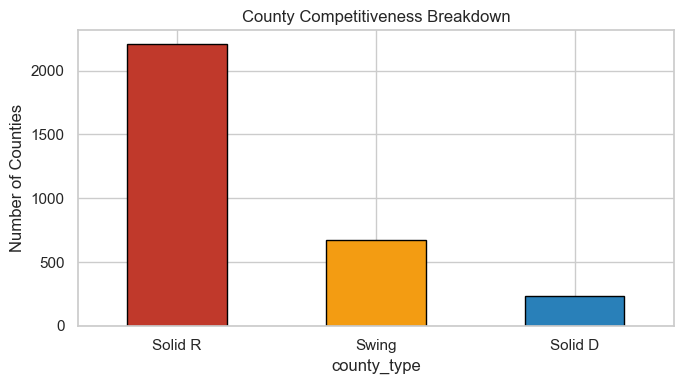

In [5]:
solid_rep = df[df["dem_vote_share"] < 0.40]
swing     = df[(df["dem_vote_share"] >= 0.40) & (df["dem_vote_share"] <= 0.60)]
solid_dem = df[df["dem_vote_share"] > 0.60]

print(f"Solid Republican (< 40%):  {len(solid_rep):4d}  ({len(solid_rep)/len(df)*100:.1f}%)")
print(f"Swing           (40-60%):  {len(swing):4d}  ({len(swing)/len(df)*100:.1f}%)")
print(f"Solid Democrat  (> 60%):   {len(solid_dem):4d}  ({len(solid_dem)/len(df)*100:.1f}%)")

bins   = [0, 0.40, 0.60, 1.01]
labels = ["Solid R", "Swing", "Solid D"]
df["county_type"] = pd.cut(df["dem_vote_share"], bins=bins, labels=labels)

plt.figure(figsize=(7, 4))
df["county_type"].value_counts().reindex(["Solid R", "Swing", "Solid D"]).plot(
    kind="bar", color=["#c0392b", "#f39c12", "#2980b9"], edgecolor="black")
plt.title("County Competitiveness Breakdown")
plt.ylabel("Number of Counties")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### (6) Feature engineering

In [6]:
# Work on a copy to avoid the fragmentation warning
eda_df = df.copy()

# Readable aliases for key ACS columns
eda_df["total_population"]  = eda_df["B01001_001E"]
eda_df["median_income"]     = eda_df["B19013_001E"]
eda_df["total_housing"]     = eda_df["B25001_001E"]
eda_df["labor_force"]       = eda_df["B23025_002E"]
eda_df["unemployed"]        = eda_df["B23025_005E"]
eda_df["below_poverty"]     = eda_df["B17001_002E"]
eda_df["white_pop"]         = eda_df["B02001_002E"]
eda_df["black_pop"]         = eda_df["B02001_003E"]
eda_df["asian_pop"]         = eda_df["B02001_005E"]
eda_df["bachelors"]         = eda_df["B15003_022E"]
eda_df["masters"]           = eda_df["B15003_023E"]
eda_df["professional_deg"]  = eda_df["B15003_024E"]
eda_df["doctorate"]         = eda_df["B15003_025E"]

# Avoid division by zero
pop = eda_df["total_population"].replace(0, np.nan)
lf  = eda_df["labor_force"].replace(0, np.nan)

# Rate features
eda_df["higher_ed_rate"]    = (eda_df["bachelors"] + eda_df["masters"] +
                               eda_df["professional_deg"] + eda_df["doctorate"]) / pop
eda_df["poverty_rate"]      = eda_df["below_poverty"] / pop
eda_df["unemployment_rate"] = eda_df["unemployed"] / lf
eda_df["white_pct"]         = eda_df["white_pop"] / pop
eda_df["black_pct"]         = eda_df["black_pop"] / pop
eda_df["asian_pct"]         = eda_df["asian_pop"] / pop
eda_df["log_population"]    = np.log1p(eda_df["total_population"])
eda_df["housing_density"]   = eda_df["total_housing"] / pop

eng = ["higher_ed_rate", "poverty_rate", "unemployment_rate",
       "white_pct", "black_pct", "asian_pct",
       "log_population", "housing_density"]

print("Engineered features summary:")
display(eda_df[eng].describe().round(3))

Engineered features summary:


,higher_ed_rate,poverty_rate,unemployment_rate,white_pct,black_pct,asian_pct,log_population,housing_density
count,3115.000,3115.000,3115.000,3115.000,3115.000,3115.000,3115.000,3115.000
mean,0.156,0.141,0.051,0.820,0.091,0.014,10.286,0.494
std,0.067,0.059,0.025,0.166,0.145,0.028,1.489,0.125
min,0.000,0.000,0.000,0.048,0.000,0.000,4.771,0.255
25%,0.110,0.100,0.036,0.750,0.007,0.003,9.316,0.427
50%,0.141,0.132,0.048,0.882,0.023,0.006,10.173,0.468
75%,0.185,0.172,0.062,0.941,0.102,0.013,11.133,0.528
max,0.560,0.579,0.304,1.000,0.878,0.426,16.122,2.227


### (7) Key features by party winner

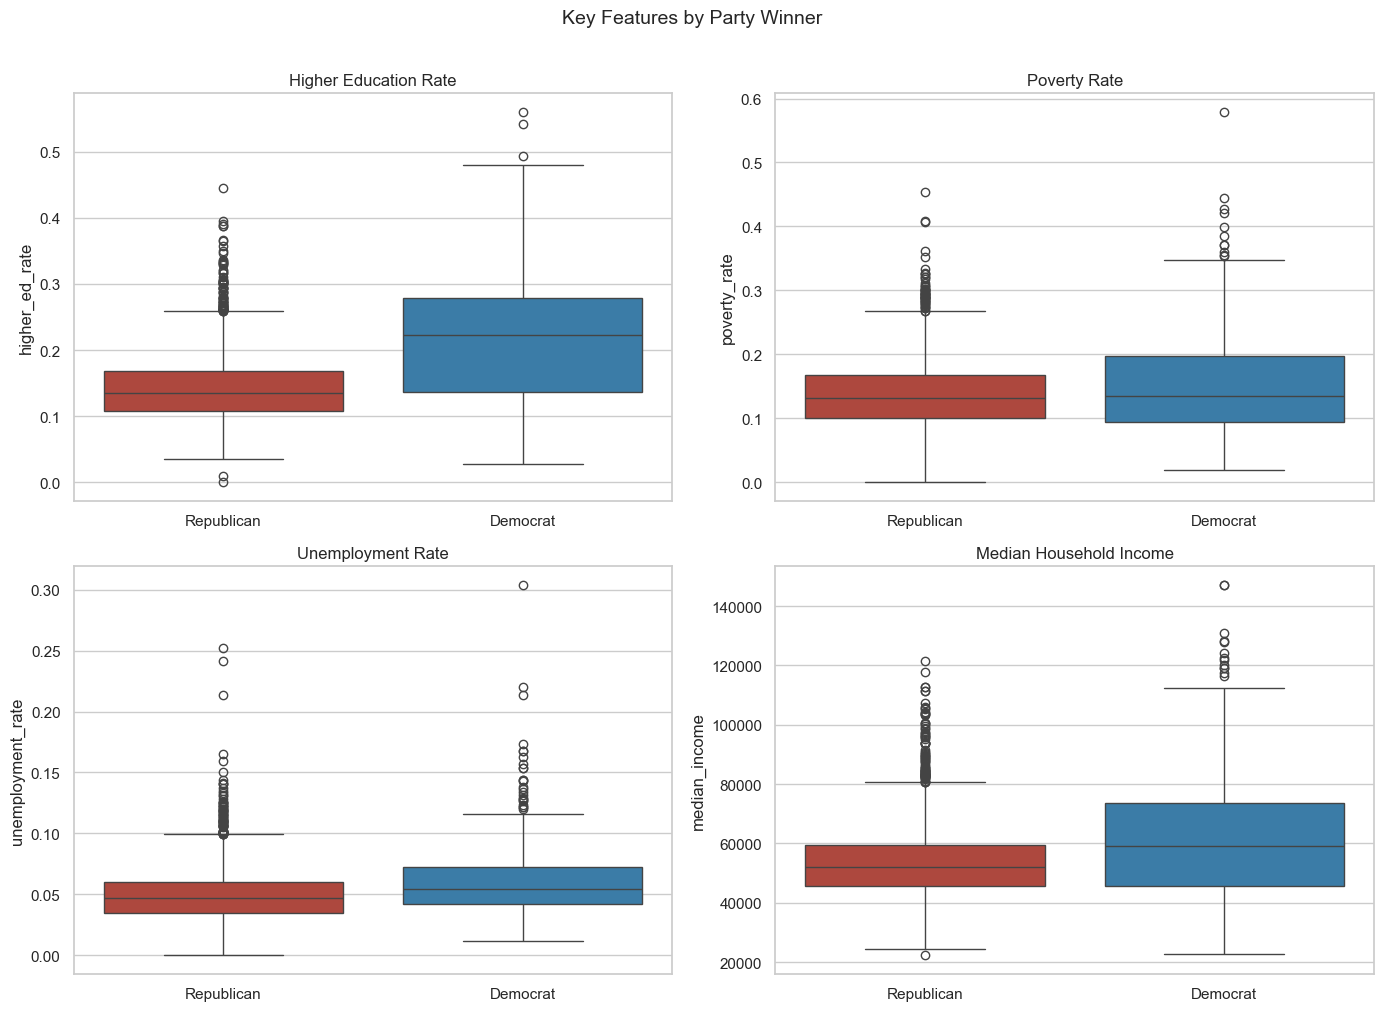

In [8]:
features_to_plot = [
    ("higher_ed_rate",    "Higher Education Rate"),
    ("poverty_rate",      "Poverty Rate"),
    ("unemployment_rate", "Unemployment Rate"),
    ("median_income",     "Median Household Income"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, features_to_plot):
    party_col = eda_df["party_winner"].map({0: "Republican", 1: "Democrat"})
    sns.boxplot(
        x=party_col,
        y=eda_df[col],
        hue=party_col,
        palette={"Republican": "#c0392b", "Democrat": "#2980b9"},
        legend=False,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("")
plt.suptitle("Key Features by Party Winner", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### (8) Racial composition by party

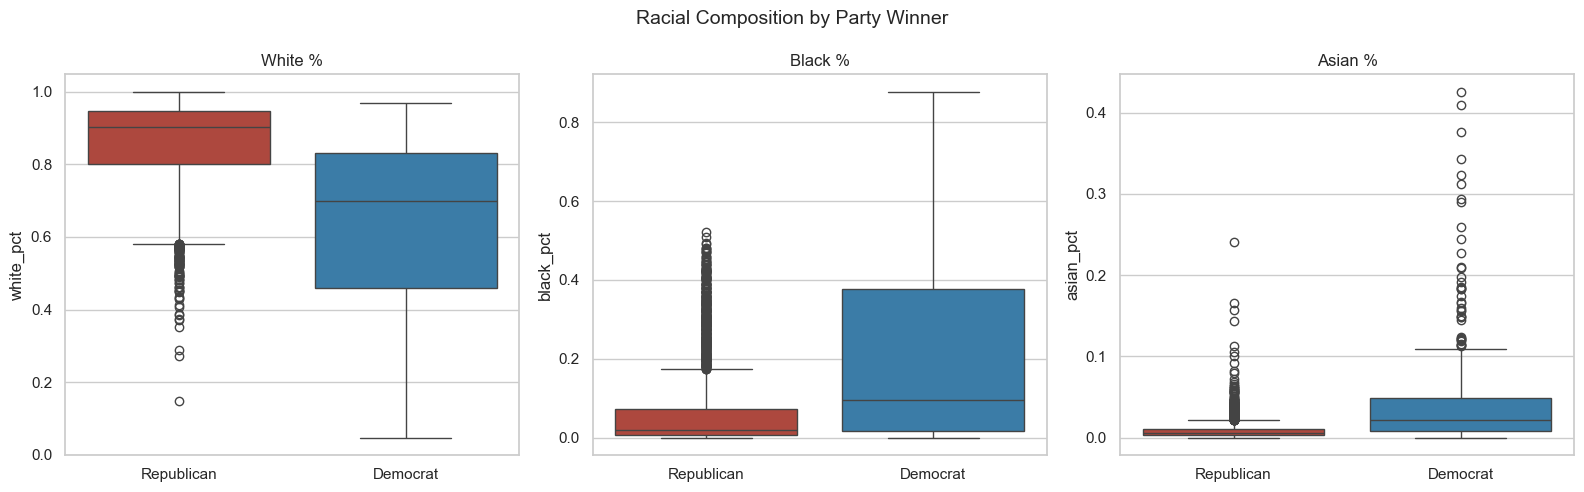

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title) in zip(axes, [
    ("white_pct", "White %"),
    ("black_pct", "Black %"),
    ("asian_pct", "Asian %")
]):
    party_col = eda_df["party_winner"].map({0: "Republican", 1: "Democrat"})
    sns.boxplot(
        x=party_col,
        y=eda_df[col],
        hue=party_col,
        palette={"Republican": "#c0392b", "Democrat": "#2980b9"},
        legend=False,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("")

plt.suptitle("Racial Composition by Party Winner", fontsize=14)
plt.tight_layout()
plt.show()

### (9) Scatter: features vs democratic vote share

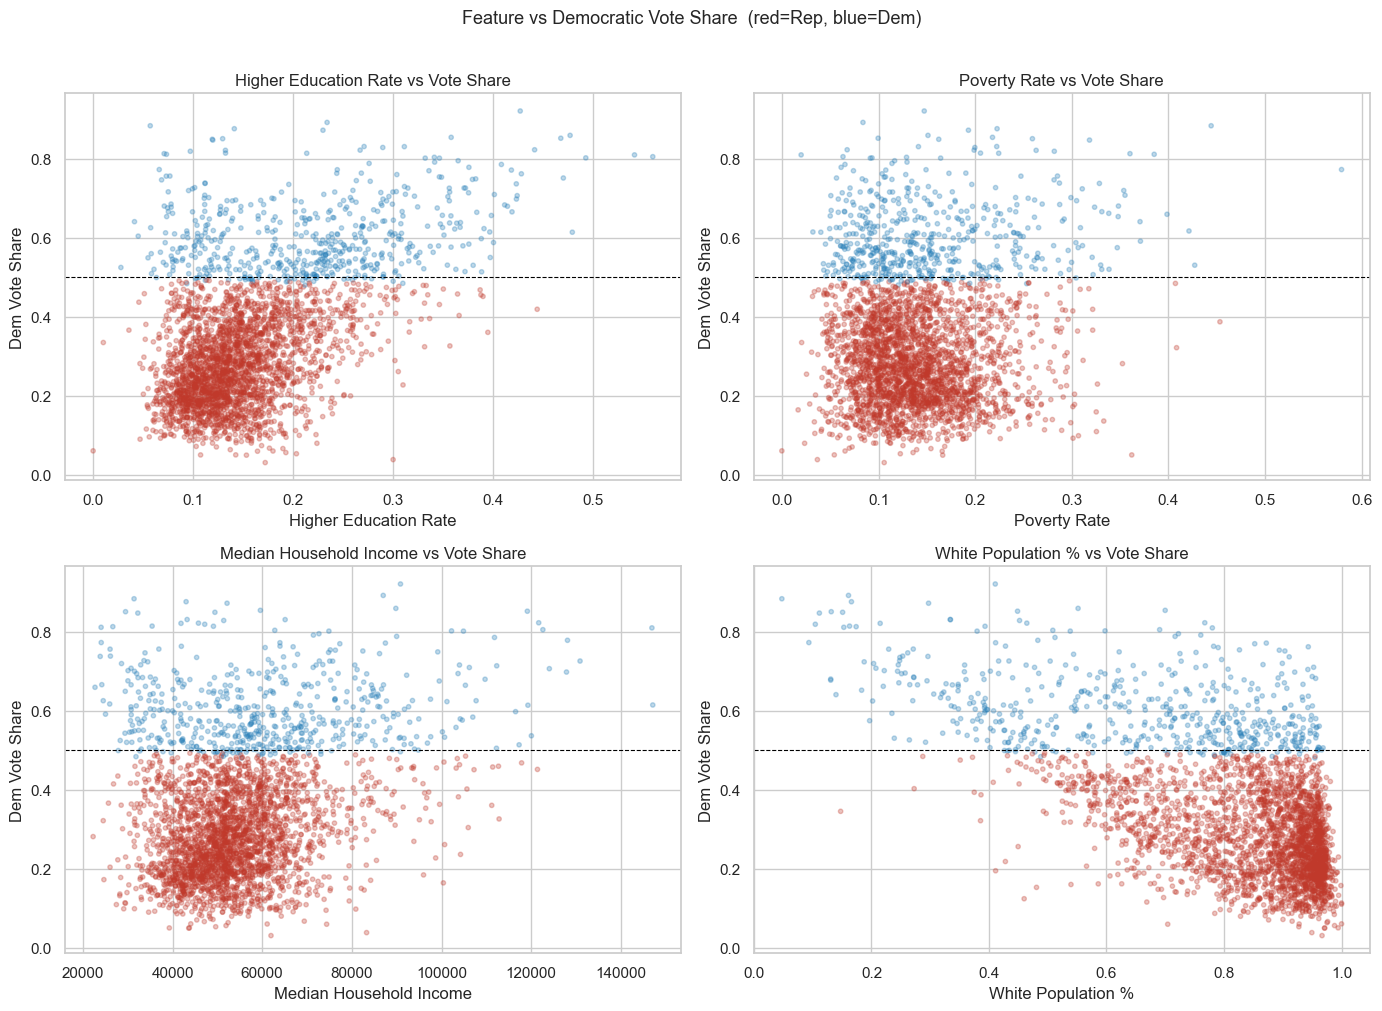

In [10]:
scatter_features = [
    ("higher_ed_rate", "Higher Education Rate"),
    ("poverty_rate",   "Poverty Rate"),
    ("median_income",  "Median Household Income"),
    ("white_pct",      "White Population %"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = eda_df["party_winner"].map({0: "#c0392b", 1: "#2980b9"})

for ax, (col, title) in zip(axes, scatter_features):
    ax.scatter(eda_df[col], eda_df["dem_vote_share"],
               c=colors, alpha=0.3, s=10)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
    ax.set_xlabel(title)
    ax.set_ylabel("Dem Vote Share")
    ax.set_title(f"{title} vs Vote Share")

plt.suptitle("Feature vs Democratic Vote Share  (red=Rep, blue=Dem)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### (10) Correlation heatmap

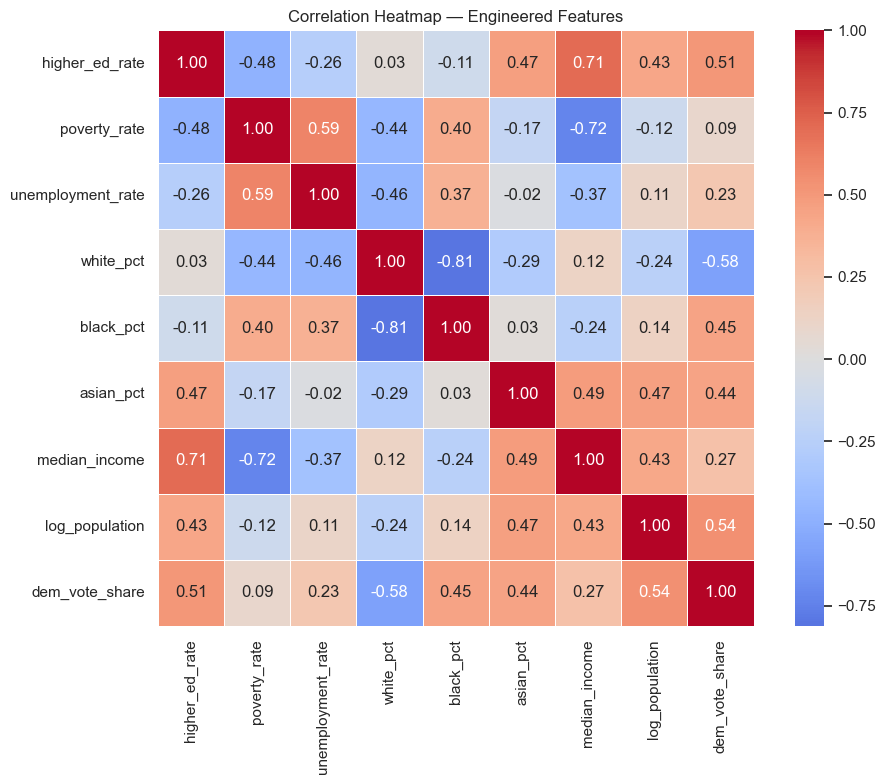

In [11]:
corr_cols = [
    "higher_ed_rate", "poverty_rate", "unemployment_rate",
    "white_pct", "black_pct", "asian_pct",
    "median_income", "log_population", "dem_vote_share"
]

corr_matrix = eda_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Engineered Features")
plt.tight_layout()
plt.show()

### (11) Mutual information — feature importance

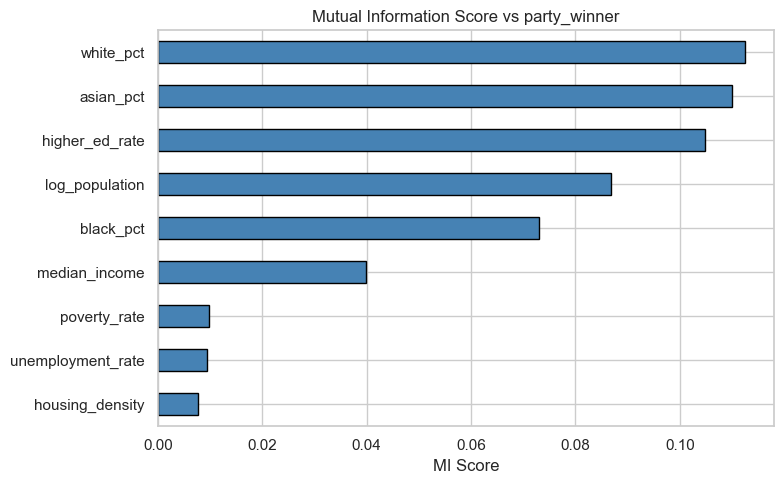


Ranking (highest = most predictive):
white_pct            0.1124
asian_pct            0.1101
higher_ed_rate       0.1048
log_population       0.0868
black_pct            0.0730
median_income        0.0399
poverty_rate         0.0098
unemployment_rate    0.0094
housing_density      0.0076
dtype: float64


In [12]:
mi_features = [
    "higher_ed_rate", "poverty_rate", "unemployment_rate",
    "white_pct", "black_pct", "asian_pct",
    "median_income", "log_population", "housing_density"
]

mi_df = eda_df[mi_features + ["party_winner"]].dropna()

mi_scores = mutual_info_classif(
    mi_df[mi_features],
    mi_df["party_winner"],
    random_state=42
)

mi_result = pd.Series(mi_scores, index=mi_features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
mi_result.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Mutual Information Score vs party_winner")
plt.xlabel("MI Score")
plt.tight_layout()
plt.show()

print("\nRanking (highest = most predictive):")
print(mi_result.sort_values(ascending=False).round(4))

### (12) State-level patterns

In [13]:
state_summary = eda_df.groupby("state").agg(
    counties      =("county_fips",    "count"),
    dem_counties  =("party_winner",   "sum"),
    avg_dem_share =("dem_vote_share", "mean"),
    avg_income    =("median_income",  "mean"),
    avg_edu       =("higher_ed_rate", "mean")
).reset_index()

state_summary["dem_county_pct"] = (
    state_summary["dem_counties"] / state_summary["counties"] * 100
).round(1)

print("Top 10 most Democrat-leaning states (by avg county dem vote share):")
display(state_summary.nlargest(10, "avg_dem_share")[
    ["state", "counties", "dem_county_pct", "avg_dem_share", "avg_income", "avg_edu"]
].round(3))

print("\nTop 10 most Republican-leaning states:")
display(state_summary.nsmallest(10, "avg_dem_share")[
    ["state", "counties", "dem_county_pct", "avg_dem_share", "avg_income", "avg_edu"]
].round(3))

Top 10 most Democrat-leaning states (by avg county dem vote share):


,state,counties,dem_county_pct,avg_dem_share,avg_income,avg_edu
8,DISTRICT OF COLUMBIA,1,100.0,0.921,90842.000,0.427
21,MASSACHUSETTS,14,100.0,0.664,80795.071,0.302
11,HAWAII,4,100.0,0.648,80076.000,0.216
45,VERMONT,14,92.9,0.609,62165.000,0.257
39,RHODE ISLAND,5,100.0,0.599,78969.000,0.297
6,CONNECTICUT,8,75.0,0.558,80333.750,0.265
30,NEW JERSEY,21,66.7,0.547,85182.095,0.268
7,DELAWARE,3,66.7,0.543,66765.667,0.213
4,CALIFORNIA,58,60.3,0.537,71109.466,0.196
29,NEW HAMPSHIRE,10,80.0,0.524,70580.700,0.250



Top 10 most Republican-leaning states:


,state,counties,dem_county_pct,avg_dem_share,avg_income,avg_edu
27,NEBRASKA,93,2.2,0.199,55715.763,0.162
36,OKLAHOMA,77,0.0,0.203,49645.351,0.133
50,WYOMING,23,8.7,0.216,63452.391,0.182
16,KANSAS,105,4.8,0.228,53264.619,0.161
25,MISSOURI,115,2.6,0.232,49389.487,0.132
42,TENNESSEE,95,3.2,0.237,48707.116,0.126
44,UTAH,29,10.3,0.241,64717.897,0.166
12,IDAHO,44,6.8,0.241,51886.636,0.151
48,WEST VIRGINIA,55,0.0,0.243,46163.455,0.124
43,TEXAS,254,8.7,0.245,54348.115,0.133


### (13) EDA summary

In [14]:
swing_mask = (eda_df["dem_vote_share"] >= 0.4) & (eda_df["dem_vote_share"] <= 0.6)

print("=" * 45)
print("EDA SUMMARY")
print("=" * 45)
print(f"Total counties:              {len(eda_df)}")
print(f"Republican-winning counties: {(eda_df['party_winner']==0).sum()}")
print(f"Democrat-winning counties:   {(eda_df['party_winner']==1).sum()}")
print(f"Class imbalance ratio:       {2576/539:.2f}x")
print(f"Swing counties (40-60%):     {swing_mask.sum()}")
print(f"Avg dem vote share:          {eda_df['dem_vote_share'].mean():.3f}")
print(f"Avg median income:           ${eda_df['median_income'].mean():,.0f}")
print(f"Avg higher ed rate:          {eda_df['higher_ed_rate'].mean():.3f}")
print(f"Avg poverty rate:            {eda_df['poverty_rate'].mean():.3f}")
print(f"Top MI feature:              white_pct (0.112)")
print(f"States covered:              {eda_df['state'].nunique()}")
print("=" * 45)

EDA SUMMARY
Total counties:              3115
Republican-winning counties: 2576
Democrat-winning counties:   539
Class imbalance ratio:       4.78x
Swing counties (40-60%):     673
Avg dem vote share:          0.333
Avg median income:           $54,917
Avg higher ed rate:          0.156
Avg poverty rate:            0.141
Top MI feature:              white_pct (0.112)
States covered:              51


### (14) Save model-ready dataset

In [15]:
eda_df.to_csv("../data/processed/model_ready_dataset.csv", index=False)
print("Saved: ../data/processed/model_ready_dataset.csv")
print(f"Final shape: {eda_df.shape}")

Saved: ../data/processed/model_ready_dataset.csv
Final shape: (3115, 184)
